# Reading and Interpolating TPXO Tidal Harmonics

This tutorial demonstrates how to read TPXO tidal harmonics data and interpolate it onto a target
grid using PyFVCOM2. This is useful for:

- Generating tidal boundary forcing for FVCOM from TPXO global tidal models
- Inspecting tidal constituent amplitudes and phases on your model domain
- Comparing TPXO tidal predictions with observations or other models

## Overview

TPXO provides global tidal harmonic data on a regular longitude/latitude grid. The data is stored
as amplitude and phase (or real/imaginary components) for each tidal constituent. To use this data
with FVCOM, we need to interpolate it onto the FVCOM grid or open boundary nodes.

The key steps are:
1. Load TPXO harmonics using `TPXOHarmonicsReader`
2. Define target interpolation coordinates
3. Use `TPXOInterpolator` to interpolate harmonics onto the target positions
4. Visualise the interpolated amplitude and phase fields

### A note on phase interpolation

Directly interpolating tidal phase is problematic because of the discontinuity at 360°/0°.
`TPXOInterpolator` handles this by decomposing each constituent's amplitude and phase into two
cartesian components using `pol2cart`, interpolating these smooth fields independently, and then
converting back to amplitude and phase with `cart2pol`.

## Prerequisites

Before running this tutorial, ensure you have:
- TPXO harmonics files in NetCDF format (here we use TPXO9.v1)
- The PyFVCOM2 package installed
- Cartopy installed (for map projections in the plots)

## Step 1: Import Required Libraries

In [1]:
from collections import namedtuple
import pathlib
import os
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from pyfvcom2.fvcom_reader import FVCOMReader
from pyfvcom2.interpolation import InterpolationCoordinates, TPXOInterpolator
from pyfvcom2.tide_reader import TPXOComplexHarmonicsReader, get_tpxo_complex_harmonics_names
from pyfvcom2.plotting import create_figure

/local1/data/scratch/jcl/miniconda/miniconda3/envs/pyfvcom2/lib/python3.11/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


## Step 2: Define the Target Grid

We reuse the same FVCOM domain as in the `interpolate_fvcom_data` tutorial to define the
target grid. The grid limits are taken from the FVCOM mesh, and we create a regular
longitude/latitude grid spanning the domain.

In [2]:
# Load FVCOM grid to get domain limits
data_dir = os.path.expanduser('~/data/pyfvcom2_doc')
fvcom_data_dir = f'{data_dir}/FVCOM_tamar_estuary'
fvcom_file_stem = 'fvcom_tamar_estuary_000'
fvcom_file_list = sorted(glob(f'{fvcom_data_dir}/{fvcom_file_stem}*.nc'))
fvcom_reader = FVCOMReader(fvcom_file_list)

# Named tuple for the grid limits
GridLims = namedtuple('GridLims', ('lon_min', 'lon_max', 'lat_min', 'lat_max'))


def get_lons_lats(grid_lims, points_per_degree):
    """Generate 1D lon and lat arrays for a regular grid."""
    n_lon = int((grid_lims.lon_max - grid_lims.lon_min) * points_per_degree)
    n_lat = int((grid_lims.lat_max - grid_lims.lat_min) * points_per_degree)
    lon = np.linspace(grid_lims.lon_min, grid_lims.lon_max, n_lon, dtype=float)
    lat = np.linspace(grid_lims.lat_min, grid_lims.lat_max, n_lat, dtype=float)
    return lon, lat


# Get grid limits from the FVCOM mesh
grid_lims = GridLims(
    fvcom_reader.lon_nodes.min(),
    fvcom_reader.lon_nodes.max(),
    fvcom_reader.lat_nodes.min(),
    fvcom_reader.lat_nodes.max(),
)

# Grid resolution
points_per_degree = 72

# Generate the regular grid
lon, lat = get_lons_lats(grid_lims, points_per_degree)
lon_2D, lat_2D = np.meshgrid(lon, lat, indexing='ij')
lon_flat = lon_2D.flatten()
lat_flat = lat_2D.flatten()

print(f'Domain: {grid_lims}')
print(f'Number of horizontal interpolation points: {lon_flat.size}')

# Create a bounding box for subsetting TPXO global data
bbox = (grid_lims.lon_min, grid_lims.lon_max, grid_lims.lat_min, grid_lims.lat_max)

Accessing FVCOM metadata from: /users/modellers/jcl/data/pyfvcom2_doc/FVCOM_tamar_estuary/fvcom_tamar_estuary_0001.nc
Domain: GridLims(lon_min=np.float32(-4.8078494), lon_max=np.float32(-3.804414), lat_min=np.float32(49.72116), lat_max=np.float32(50.519005))
Number of horizontal interpolation points: 4104


## Step 3: Create Interpolation Coordinates

Bundle the target positions into an `InterpolationCoordinates` object. For tidal harmonics
we only need horizontal coordinates — there is no time or depth dimension.

In [3]:
interp_coords = InterpolationCoordinates(
    dates=None,
    x3=None,
    x1=lon_flat,
    x2=lat_flat,
    horizontal_coordinate_system='geographic',
    vertical_coordinate_system='z',
)

## Step 4: Read and Interpolate Elevation Harmonics (zeta)

We use `TPXOHarmonicsReader` to load the tidal elevation harmonics from the TPXO9 file,
then use `TPXOInterpolator` to interpolate them onto our target grid.

The `get_tpxo_harmonics_names` helper returns the correct variable names for the TPXO
amplitude/phase format. For zeta, these are `ha` (amplitude) and `hp` (phase).

The TPXO file uses 0–360° longitudes, while the FVCOM domain uses negative longitudes
(~-4°). `TPXOInterpolator` detects and corrects this mismatch automatically.

In [4]:
# Constituent list
constituents = ['M2', 'S2', 'K1', 'O1']

# TPXO files
tpxo_h_files = {}
for c in constituents:
    tpxo_h_files[c] = f'{data_dir}/TPXO/DATA/Atlas10v2/h_{c.lower()}_tpxo10_atlas_30_v2.nc'

# Read harmonics
h_reader = TPXOComplexHarmonicsReader(tpxo_h_files)
h_var_names = get_tpxo_complex_harmonics_names('zeta')
h_harmonics = h_reader.read_harmonics(constituents, h_var_names, fill_land=False, bbox=bbox, bbox_margin=0.1)

print(f'Loaded constituents: {h_harmonics.constituents}')
print(f'Amplitude shape: {np.asarray(h_harmonics.amplitudes).shape}')

# Interpolate onto target grid
h_interpolator = TPXOInterpolator(h_harmonics)
h_result = h_interpolator.interpolate(interp_coords)

print(f'Interpolated amplitude shape: {h_result.amplitudes.shape}')  # (n_points, n_constituents)

Loaded constituents: ['M2', 'S2', 'K1', 'O1']
Amplitude shape: (4, 36, 30)
Interpolated amplitude shape: (4104, 4)


## Step 5a: Plot Original (Uninterpolated) Elevation Data

Before looking at the interpolated result, let’s visualise the raw TPXO elevation
harmonics over the same domain. The TPXO grid uses 0–360° longitudes, so we
shift values > 180° to negative before subsetting to the domain extent.

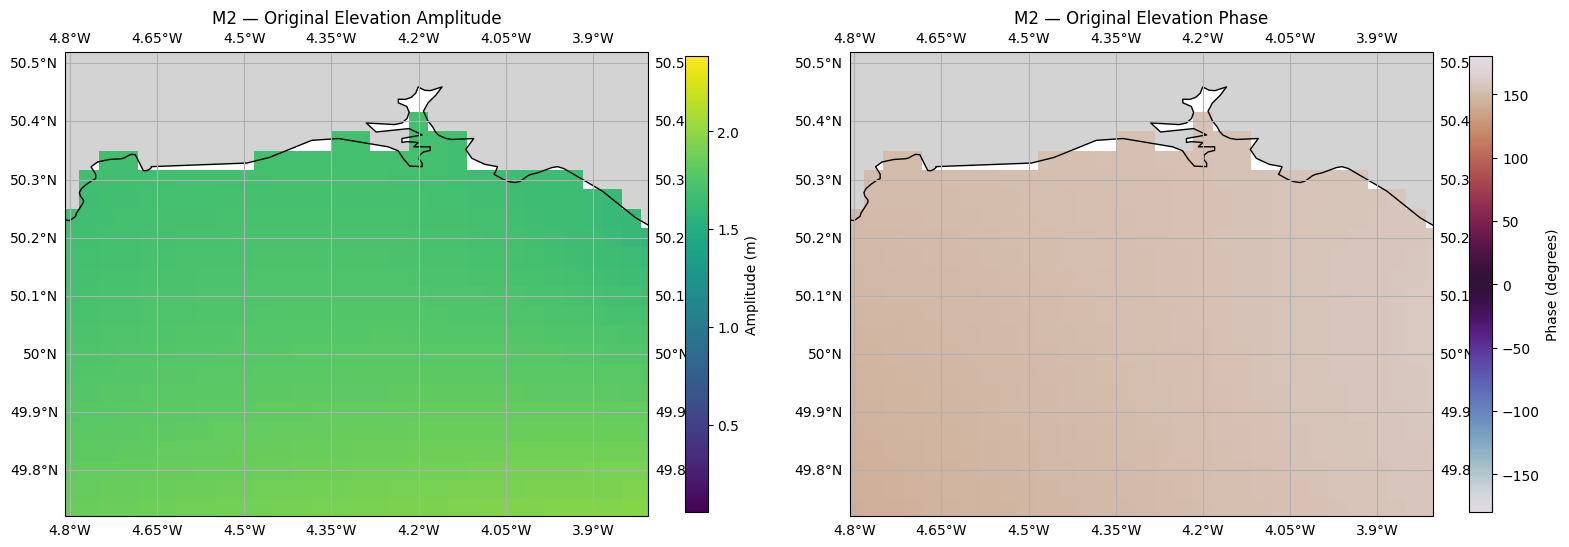

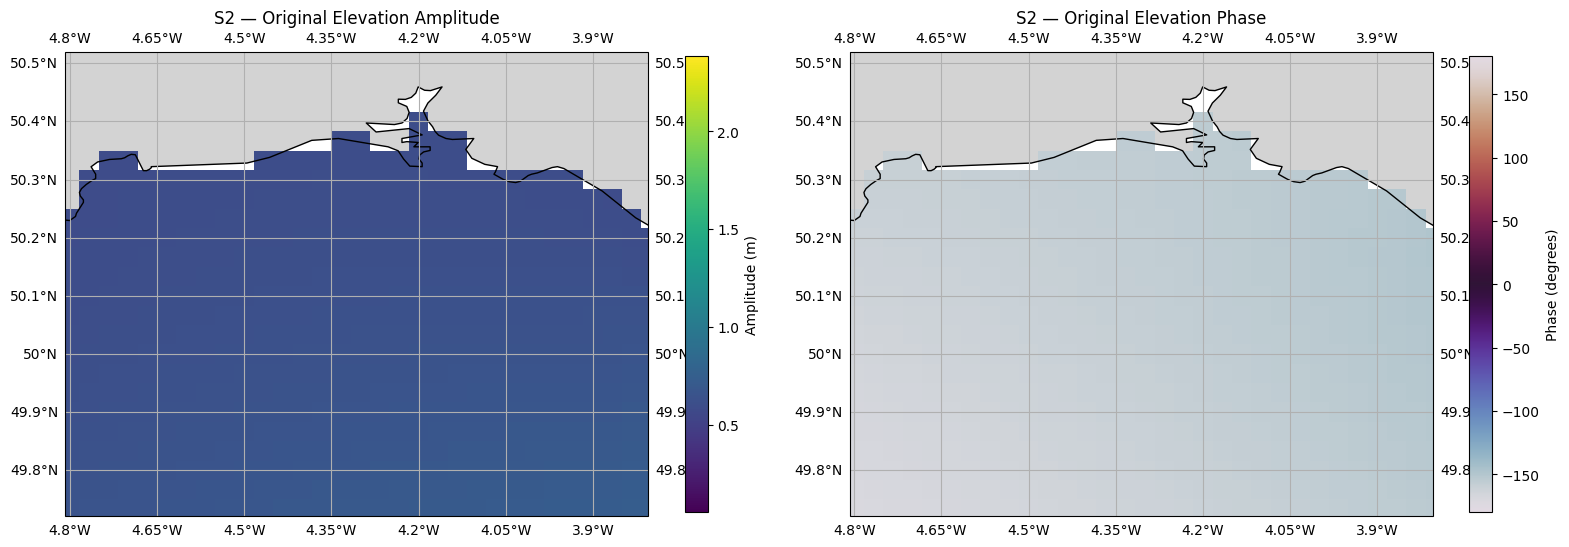

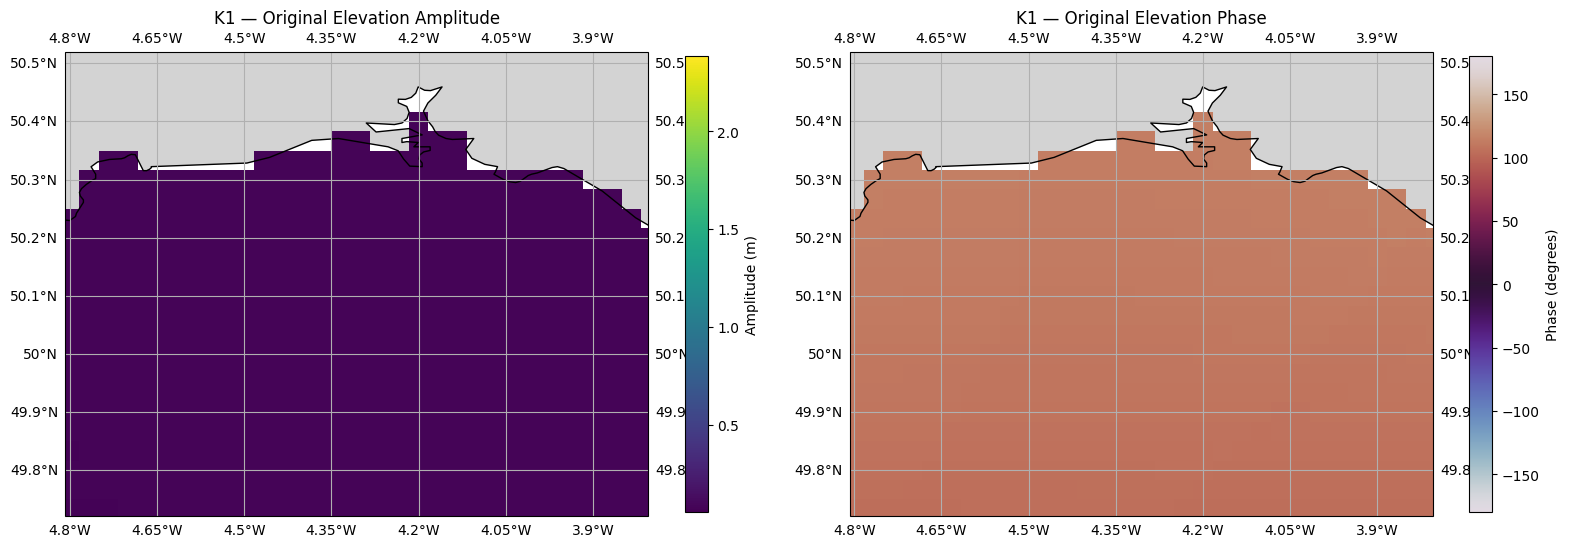

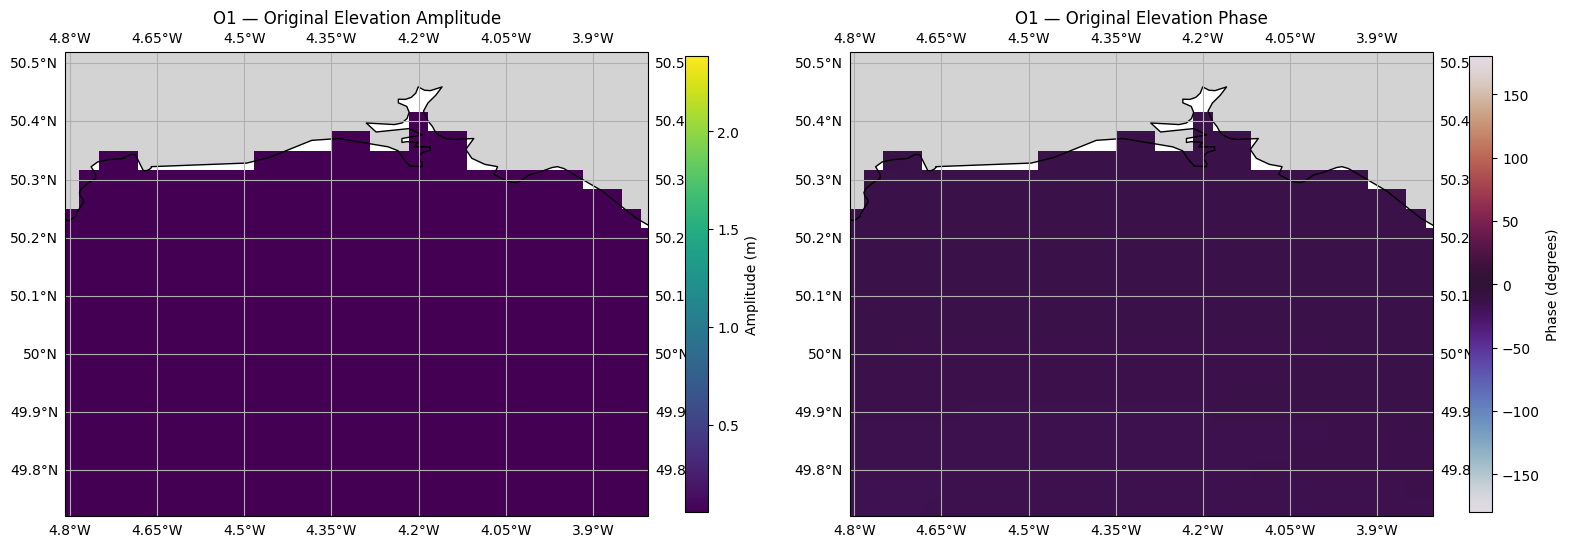

In [5]:
extent = [grid_lims.lon_min, grid_lims.lon_max, grid_lims.lat_min, grid_lims.lat_max]

# Prepare the raw TPXO elevation grid for plotting
h_lon = np.asarray(h_harmonics.longitude)
h_lat = np.asarray(h_harmonics.latitude)

h_lon_sub_2d, h_lat_sub_2d = np.meshgrid(h_lon, h_lat, indexing='ij')

h_amp = np.asarray(h_harmonics.amplitudes)  # (nc, nx, ny)
h_phase = np.asarray(h_harmonics.phases)

# Compute shared colorbar limits across all constituents for original and interpolated
h_amp_vmin = np.nanmin(h_amp)
h_amp_vmax = np.nanmax(h_amp)

for c_idx, constituent in enumerate(h_harmonics.constituents):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                             subplot_kw={'projection': ccrs.PlateCarree()})

    # Amplitude
    pc = axes[0].pcolormesh(h_lon_sub_2d, h_lat_sub_2d, h_amp[c_idx],
                            cmap='viridis', transform=ccrs.PlateCarree(), shading='auto',
                            vmin=h_amp_vmin, vmax=h_amp_vmax)
    axes[0].coastlines(resolution='10m')
    axes[0].add_feature(cfeature.LAND, facecolor='lightgrey')
    axes[0].gridlines(draw_labels=True)
    axes[0].set_extent(extent, crs=ccrs.PlateCarree())
    cbar = plt.colorbar(pc, ax=axes[0], shrink=0.8)
    cbar.set_label('Amplitude (m)')
    axes[0].set_title(f'{constituent} — Original Elevation Amplitude')

    # Phase
    pc = axes[1].pcolormesh(h_lon_sub_2d, h_lat_sub_2d, h_phase[c_idx],
                            cmap='twilight', transform=ccrs.PlateCarree(), shading='auto',
                            vmin=-180, vmax=180)
    axes[1].coastlines(resolution='10m')
    axes[1].add_feature(cfeature.LAND, facecolor='lightgrey')
    axes[1].gridlines(draw_labels=True)
    axes[1].set_extent(extent, crs=ccrs.PlateCarree())
    cbar = plt.colorbar(pc, ax=axes[1], shrink=0.8)
    cbar.set_label('Phase (degrees)')
    axes[1].set_title(f'{constituent} — Original Elevation Phase')

    plt.tight_layout()
    plt.show()

## Step 5b: Plot Interpolated Elevation Amplitude and Phase

Plot the interpolated tidal amplitude and phase for each constituent.

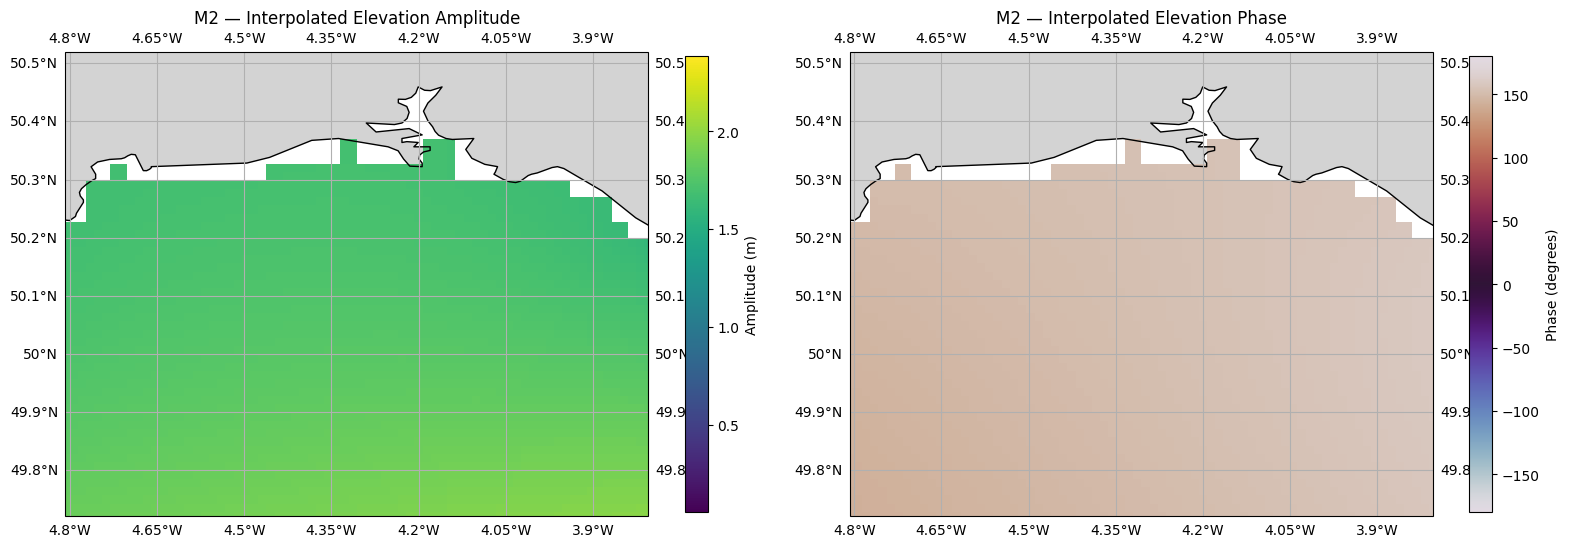

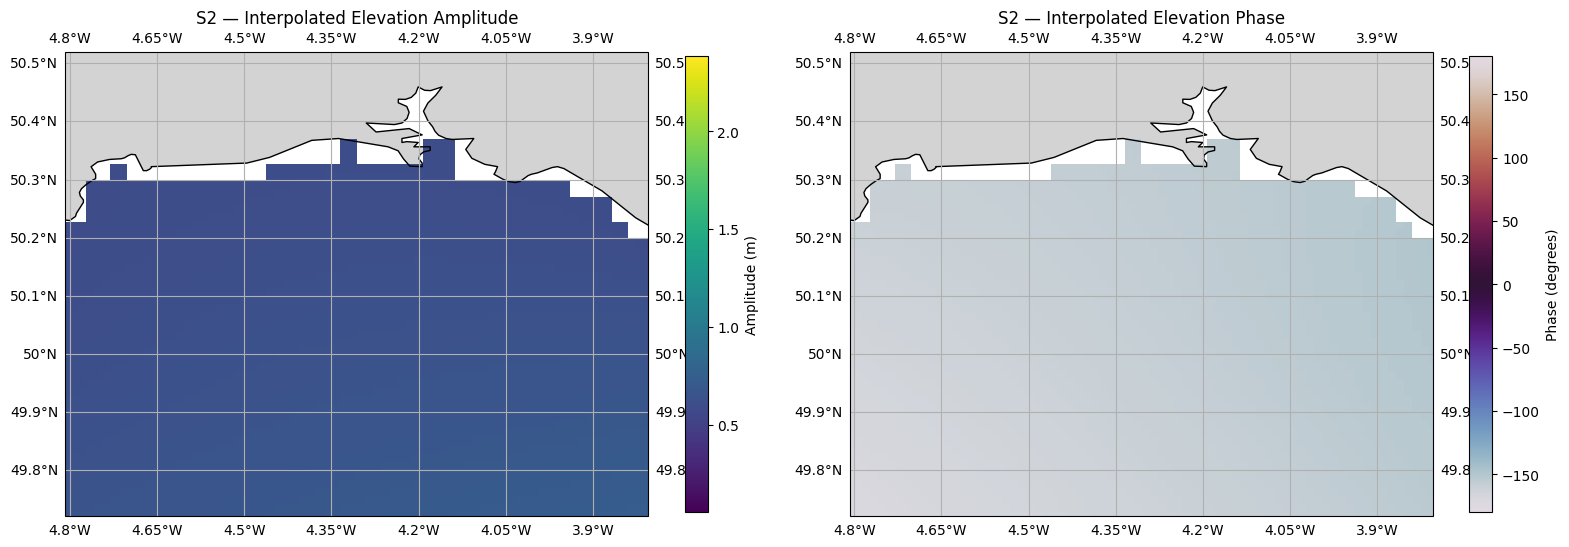

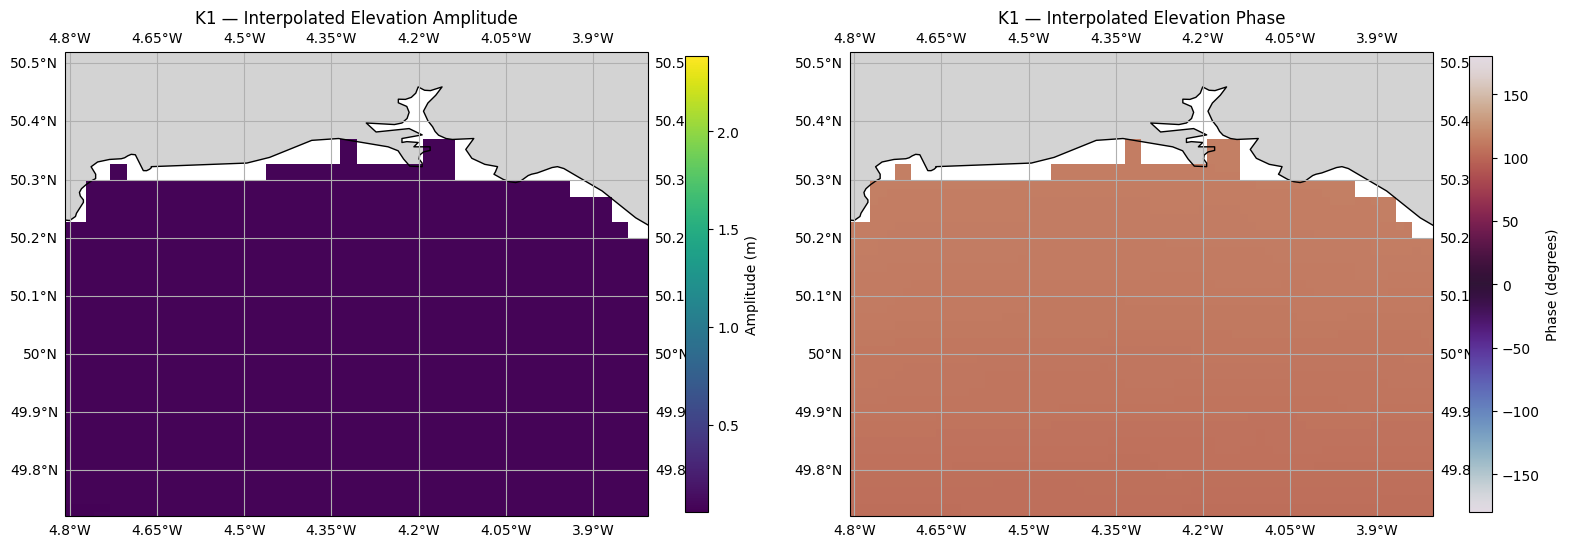

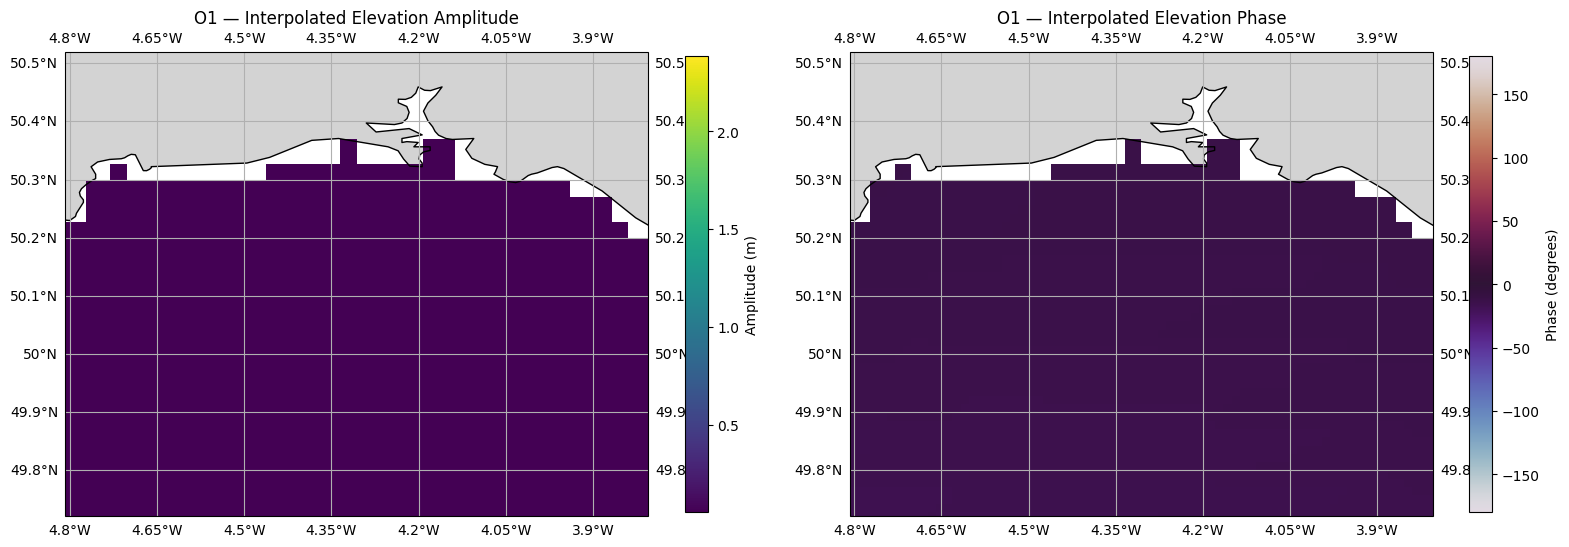

In [6]:
n_lon, n_lat = lon_2D.shape

for c_idx, constituent in enumerate(h_result.constituents):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                             subplot_kw={'projection': ccrs.PlateCarree()})

    # Reshape flat interpolated data back to 2D grid
    amp_2d = h_result.amplitudes[:, c_idx].reshape(n_lon, n_lat)
    phase_2d = h_result.phases[:, c_idx].reshape(n_lon, n_lat)

    # Amplitude
    pc = axes[0].pcolormesh(lon_2D, lat_2D, amp_2d, cmap='viridis',
                            transform=ccrs.PlateCarree(), shading='auto',
                            vmin=h_amp_vmin, vmax=h_amp_vmax)
    axes[0].coastlines(resolution='10m')
    axes[0].add_feature(cfeature.LAND, facecolor='lightgrey')
    axes[0].gridlines(draw_labels=True)
    axes[0].set_extent(extent, crs=ccrs.PlateCarree())
    cbar = plt.colorbar(pc, ax=axes[0], shrink=0.8)
    cbar.set_label('Amplitude (m)')
    axes[0].set_title(f'{constituent} — Interpolated Elevation Amplitude')

    # Phase
    pc = axes[1].pcolormesh(lon_2D, lat_2D, phase_2d, cmap='twilight',
                            transform=ccrs.PlateCarree(), shading='auto',
                            vmin=-180, vmax=180)
    axes[1].coastlines(resolution='10m')
    axes[1].add_feature(cfeature.LAND, facecolor='lightgrey')
    axes[1].gridlines(draw_labels=True)
    axes[1].set_extent(extent, crs=ccrs.PlateCarree())
    cbar = plt.colorbar(pc, ax=axes[1], shrink=0.8)
    cbar.set_label('Phase (degrees)')
    axes[1].set_title(f'{constituent} — Interpolated Elevation Phase')

    plt.tight_layout()
    plt.show()

## Step 6: Read and Interpolate Velocity Harmonics (u and v)

The TPXO velocity file contains both u (west-east) and v (south-north) components, each
on their own grid (`lon_u`/`lat_u` and `lon_v`/`lat_v`). We read and interpolate them
separately.

Note: TPXO9 velocity amplitudes are in cm/s.

In [7]:
# Bathy file
bathy_file = f'{data_dir}/TPXO/DATA/Atlas10v2/grid_tpxo10atlas_v2.nc'

# TPXO files
tpxo_u_files = {}
for c in constituents:
    tpxo_u_files[c] = f'{data_dir}/TPXO/DATA/Atlas10v2/u_{c.lower()}_tpxo10_atlas_30_v2.nc'

# Read harmonics
u_reader = TPXOComplexHarmonicsReader(tpxo_u_files)
u_var_names = get_tpxo_complex_harmonics_names('u')
u_harmonics = u_reader.read_harmonics(constituents, u_var_names, fill_land=False, bbox=bbox, bbox_margin=0.1, bathy_file=bathy_file)

# Read v-component harmonics
v_reader = TPXOComplexHarmonicsReader(tpxo_u_files)
v_var_names = get_tpxo_complex_harmonics_names('v')
v_harmonics = v_reader.read_harmonics(constituents, v_var_names, fill_land=False, bbox=bbox, bbox_margin=0.1, bathy_file=bathy_file)

print(f'u amplitude shape: {np.asarray(u_harmonics.amplitudes).shape}')
print(f'v amplitude shape: {np.asarray(v_harmonics.amplitudes).shape}')

# Interpolate both components onto the target grid
u_interpolator = TPXOInterpolator(u_harmonics, interp_method='nearest')
u_result = u_interpolator.interpolate(interp_coords)

v_interpolator = TPXOInterpolator(v_harmonics, interp_method='nearest')
v_result = v_interpolator.interpolate(interp_coords)

print(f'Interpolated u amplitude shape: {u_result.amplitudes.shape}')
print(f'Interpolated v amplitude shape: {v_result.amplitudes.shape}')

u amplitude shape: (4, 36, 30)
v amplitude shape: (4, 36, 30)
Interpolated u amplitude shape: (4104, 4)
Interpolated v amplitude shape: (4104, 4)


## Step 7a: Plot Original (Uninterpolated) Velocity Data

The raw TPXO velocity harmonics for u and v, subset to the same domain.

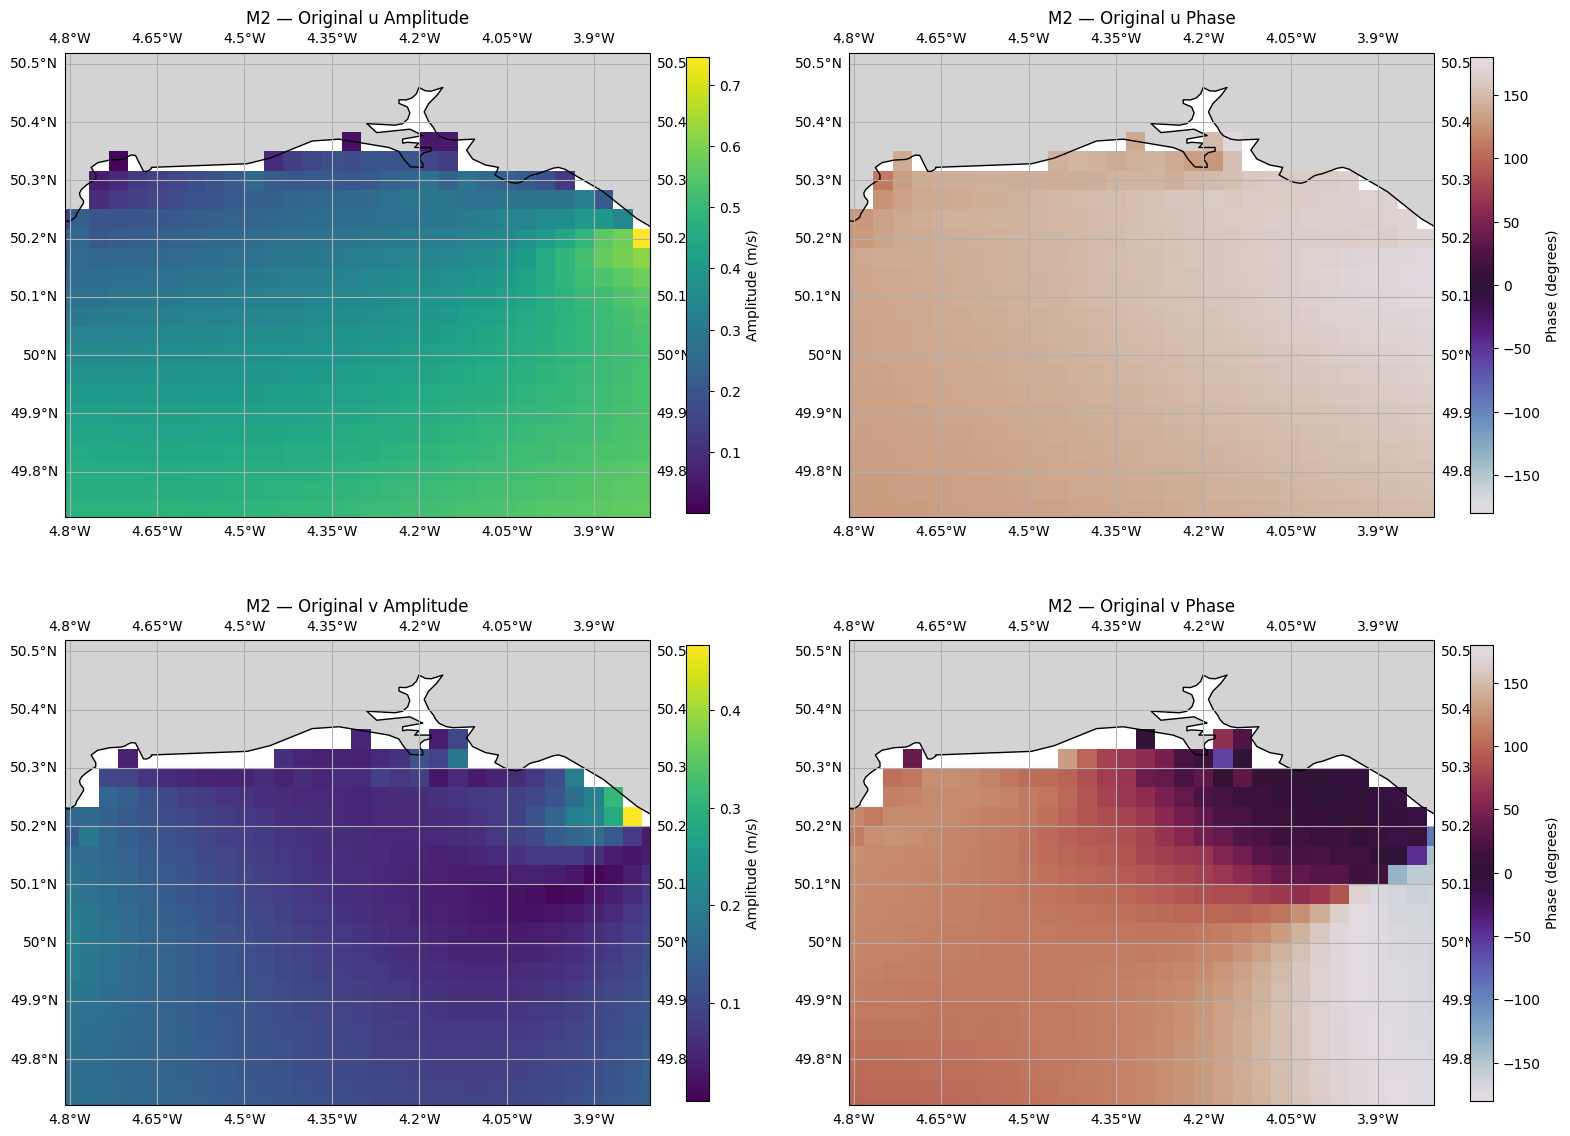

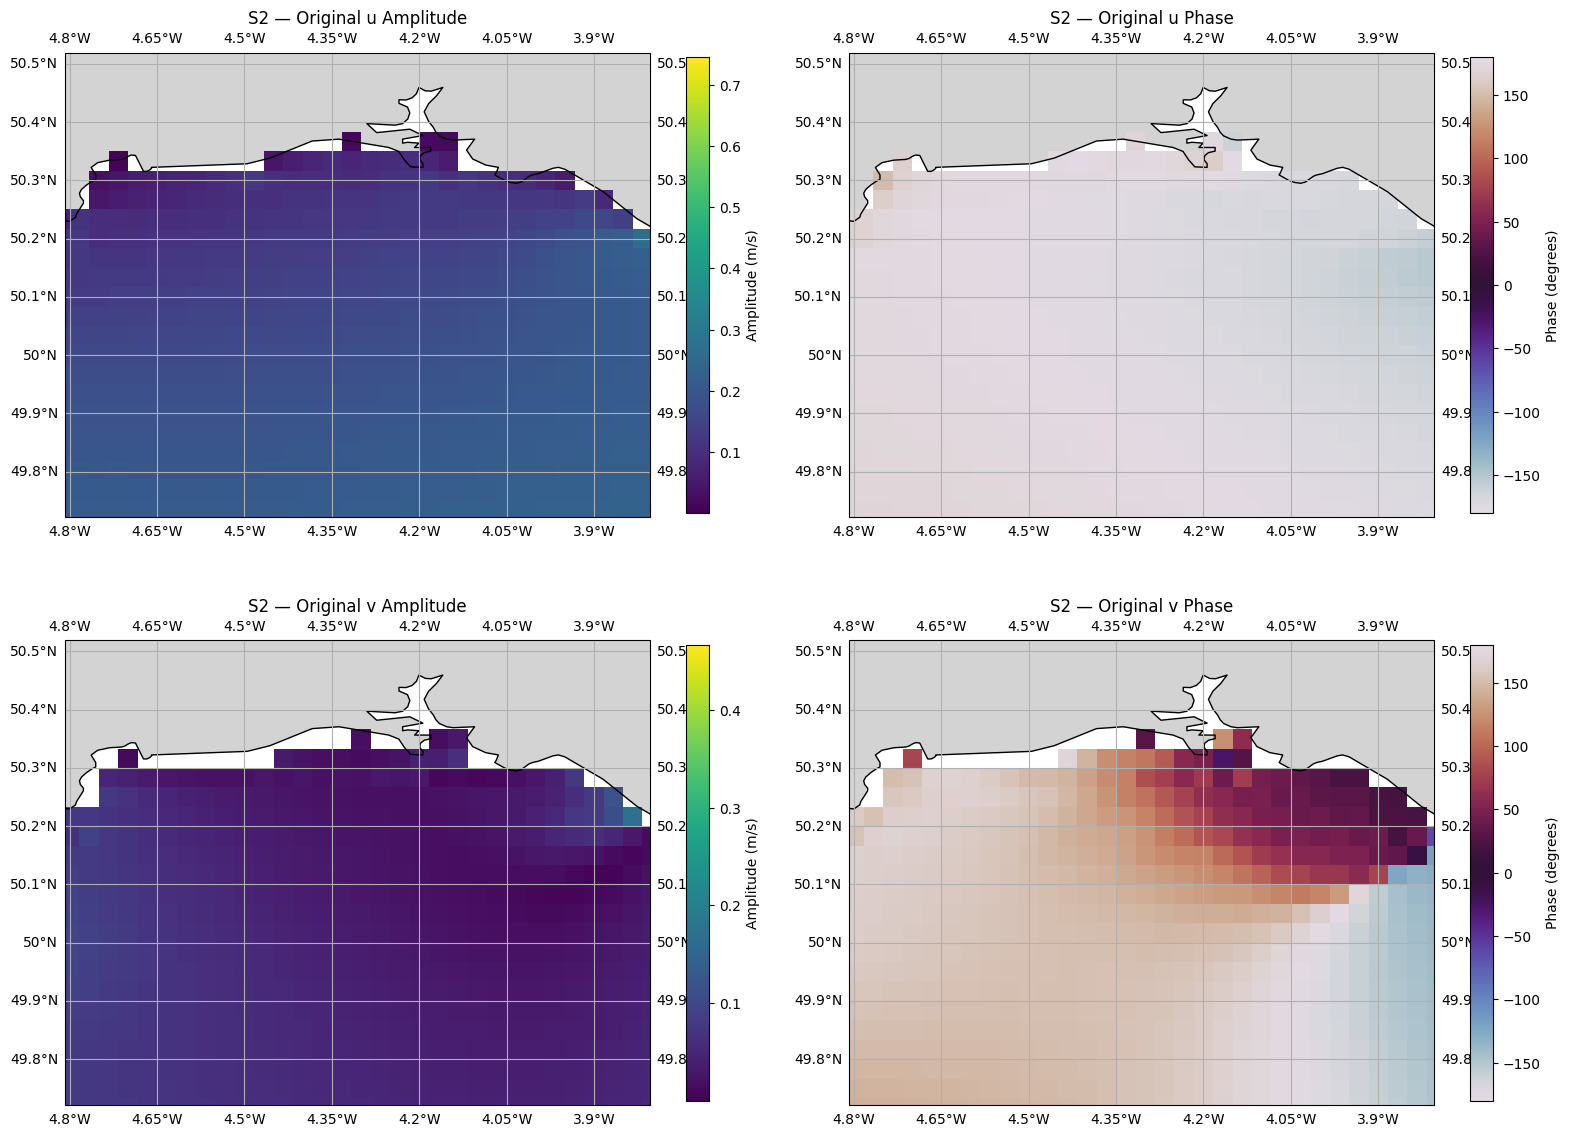

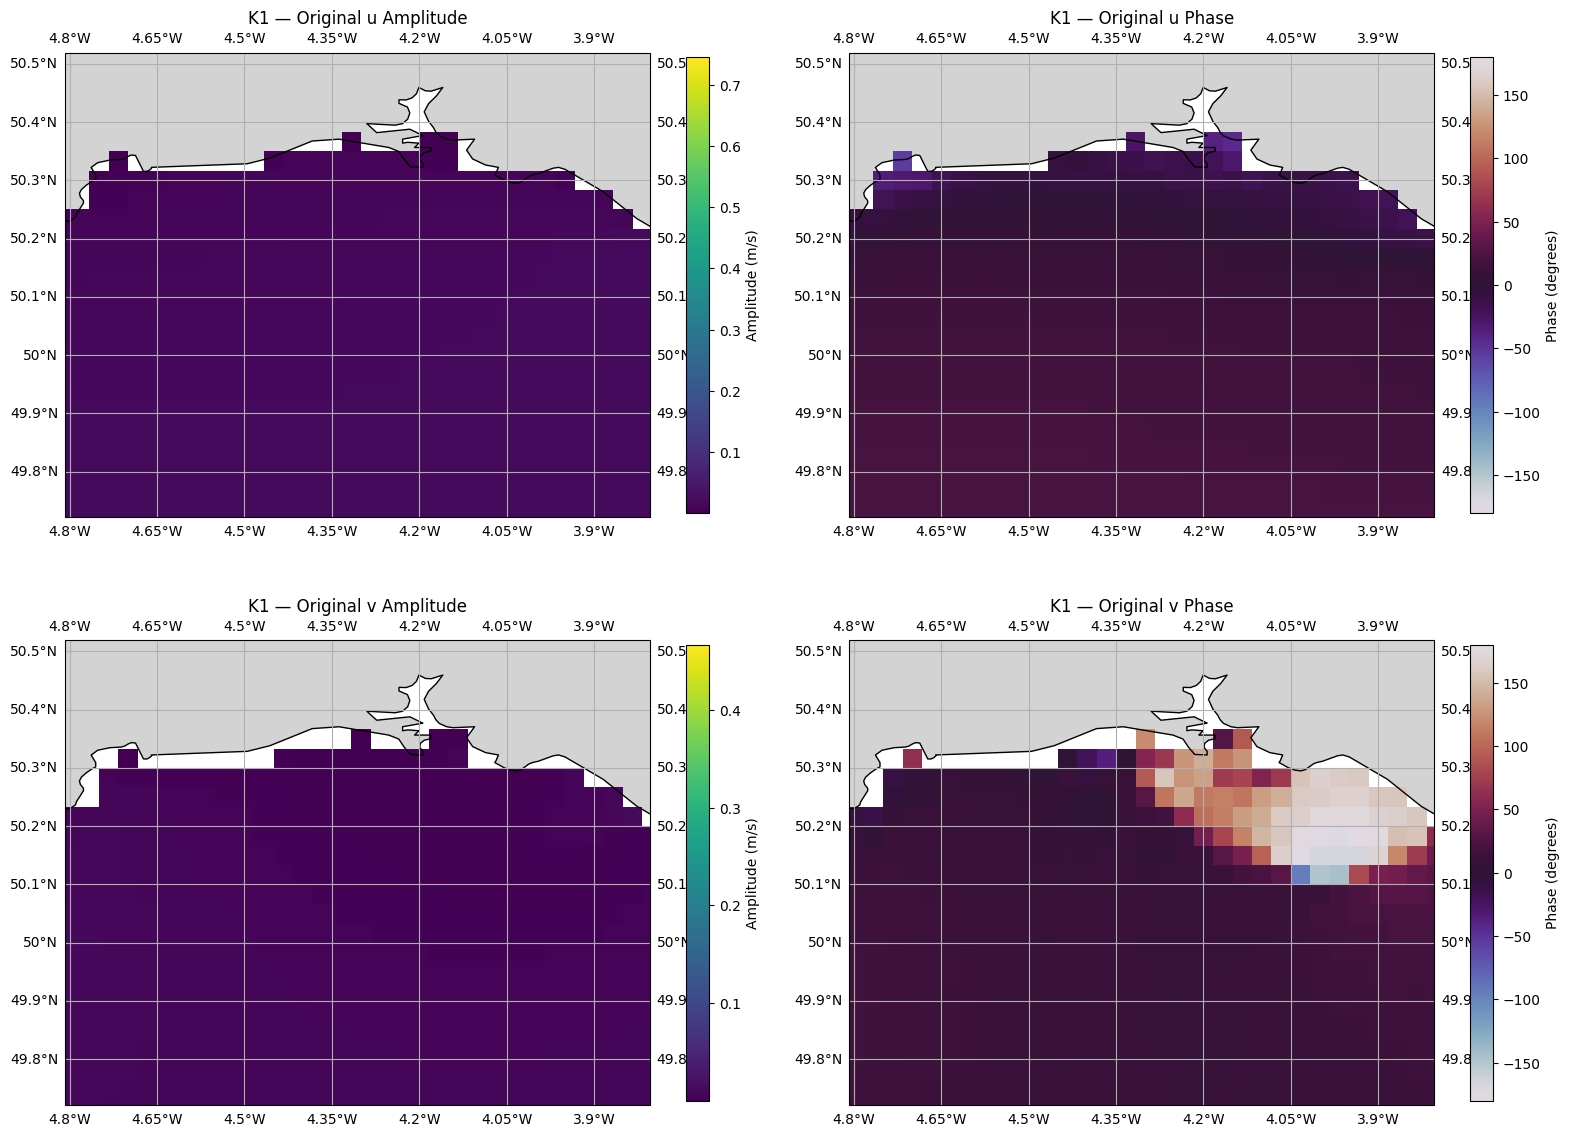

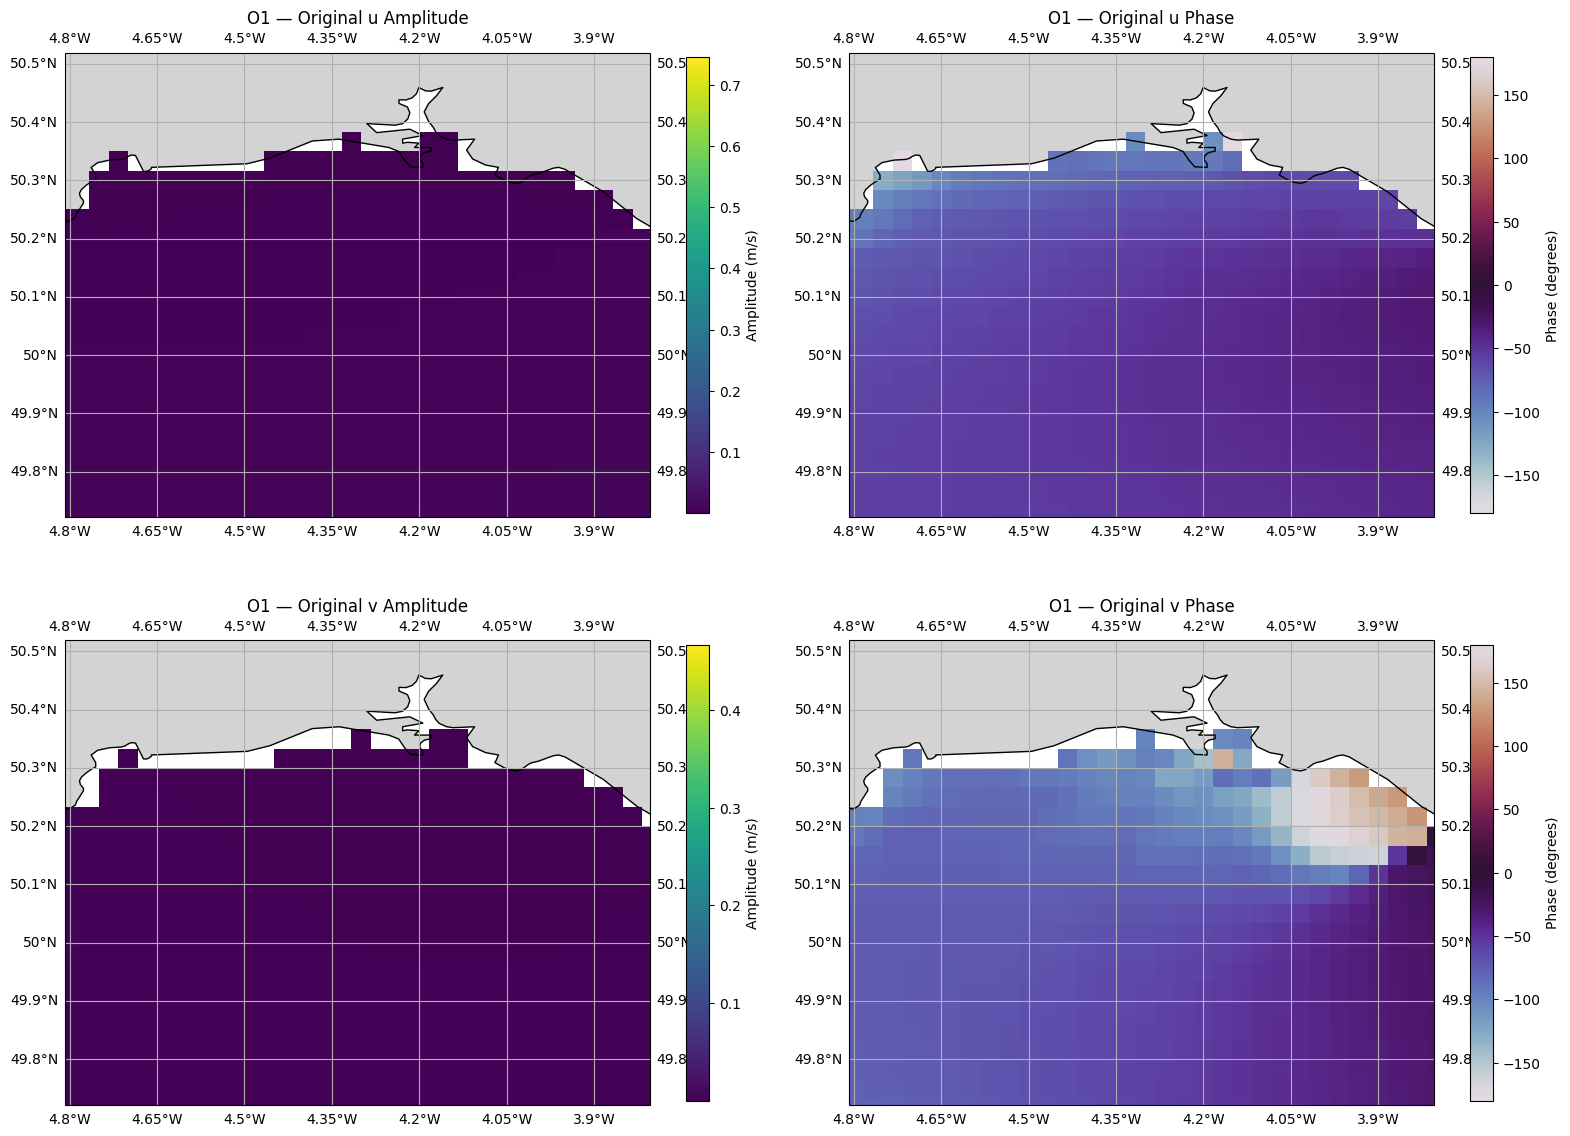

In [8]:
# Prepare the raw TPXO velocity grids for plotting
u_lon = np.asarray(u_harmonics.longitude)
u_lat = np.asarray(u_harmonics.latitude)
u_lon_2d, u_lat_2d = np.meshgrid(u_lon, u_lat, indexing='ij')
v_lon = np.asarray(v_harmonics.longitude)
v_lat = np.asarray(v_harmonics.latitude)
v_lon_2d, v_lat_2d = np.meshgrid(v_lon, v_lat, indexing='ij')

u_amp = np.asarray(u_harmonics.amplitudes)  # (nc, nx, ny)
u_phase = np.asarray(u_harmonics.phases)
v_amp = np.asarray(v_harmonics.amplitudes)  # (nc, nx, ny)
v_phase = np.asarray(v_harmonics.phases)

# Compute shared colorbar limits across all constituents for original and interpolated
u_amp_vmin = np.nanmin(u_amp)
u_amp_vmax = np.nanmax(u_amp)
v_amp_vmin = np.nanmin(v_amp)
v_amp_vmax = np.nanmax(v_amp)

for c_idx, constituent in enumerate(constituents):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12),
                             subplot_kw={'projection': ccrs.PlateCarree()})

    # u amplitude
    pc = axes[0, 0].pcolormesh(u_lon_2d, u_lat_2d, u_amp[c_idx],
                               cmap='viridis', transform=ccrs.PlateCarree(), shading='auto',
                               vmin=u_amp_vmin, vmax=u_amp_vmax)
    axes[0, 0].coastlines(resolution='10m')
    axes[0, 0].add_feature(cfeature.LAND, facecolor='lightgrey')
    axes[0, 0].gridlines(draw_labels=True)
    axes[0, 0].set_extent(extent, crs=ccrs.PlateCarree())
    cbar = plt.colorbar(pc, ax=axes[0, 0], shrink=0.8)
    cbar.set_label('Amplitude (m/s)')
    axes[0, 0].set_title(f'{constituent} — Original u Amplitude')

    # u phase
    pc = axes[0, 1].pcolormesh(u_lon_2d, u_lat_2d, u_phase[c_idx],
                               cmap='twilight', transform=ccrs.PlateCarree(), shading='auto',
                               vmin=-180, vmax=180)
    axes[0, 1].coastlines(resolution='10m')
    axes[0, 1].add_feature(cfeature.LAND, facecolor='lightgrey')
    axes[0, 1].gridlines(draw_labels=True)
    axes[0, 1].set_extent(extent, crs=ccrs.PlateCarree())
    cbar = plt.colorbar(pc, ax=axes[0, 1], shrink=0.8)
    cbar.set_label('Phase (degrees)')
    axes[0, 1].set_title(f'{constituent} — Original u Phase')

    # v amplitude
    pc = axes[1, 0].pcolormesh(v_lon_2d, v_lat_2d, v_amp[c_idx],
                               cmap='viridis', transform=ccrs.PlateCarree(), shading='auto',
                               vmin=v_amp_vmin, vmax=v_amp_vmax)
    axes[1, 0].coastlines(resolution='10m')
    axes[1, 0].add_feature(cfeature.LAND, facecolor='lightgrey')
    axes[1, 0].gridlines(draw_labels=True)
    axes[1, 0].set_extent(extent, crs=ccrs.PlateCarree())
    cbar = plt.colorbar(pc, ax=axes[1, 0], shrink=0.8)
    cbar.set_label('Amplitude (m/s)')
    axes[1, 0].set_title(f'{constituent} — Original v Amplitude')

    # v phase
    pc = axes[1, 1].pcolormesh(v_lon_2d, v_lat_2d, v_phase[c_idx],
                               cmap='twilight', transform=ccrs.PlateCarree(), shading='auto',
                               vmin=-180, vmax=180)
    axes[1, 1].coastlines(resolution='10m')
    axes[1, 1].add_feature(cfeature.LAND, facecolor='lightgrey')
    axes[1, 1].gridlines(draw_labels=True)
    axes[1, 1].set_extent(extent, crs=ccrs.PlateCarree())
    cbar = plt.colorbar(pc, ax=axes[1, 1], shrink=0.8)
    cbar.set_label('Phase (degrees)')
    axes[1, 1].set_title(f'{constituent} — Original v Phase')

    plt.tight_layout()
    plt.show()

## Step 7b: Plot Interpolated Velocity Amplitude and Phase

Plot the interpolated u and v velocity amplitudes and phases for each constituent.

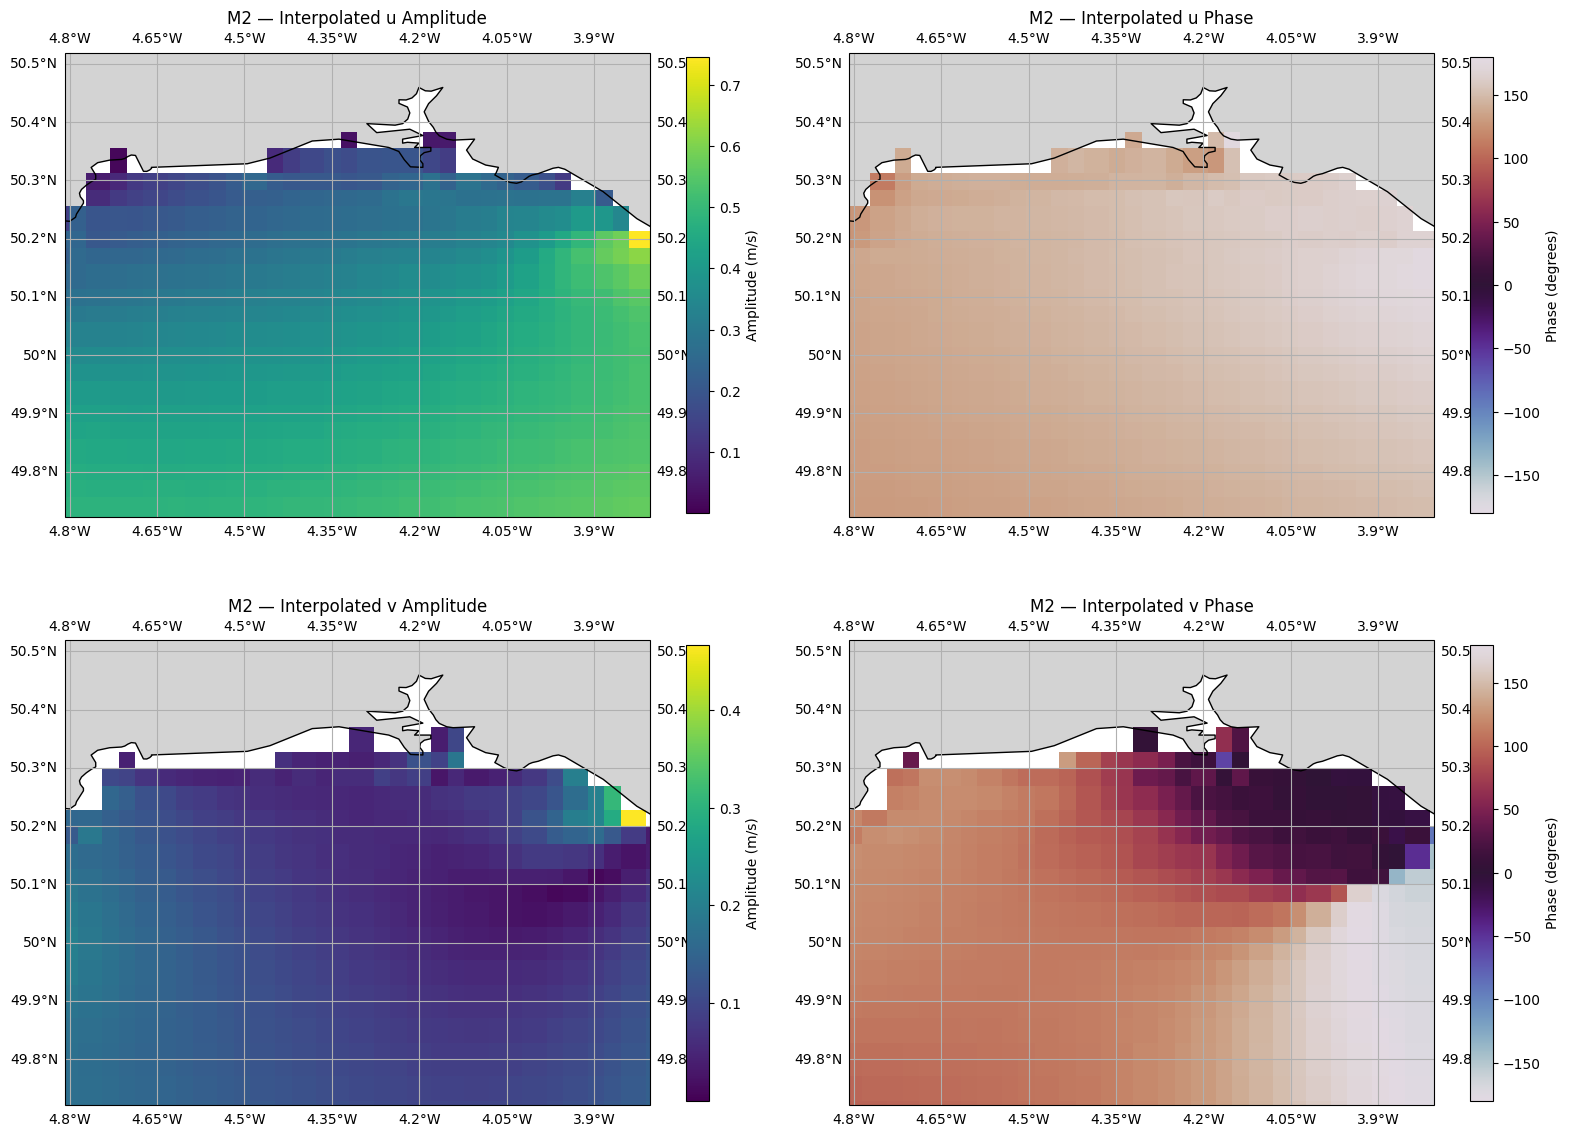

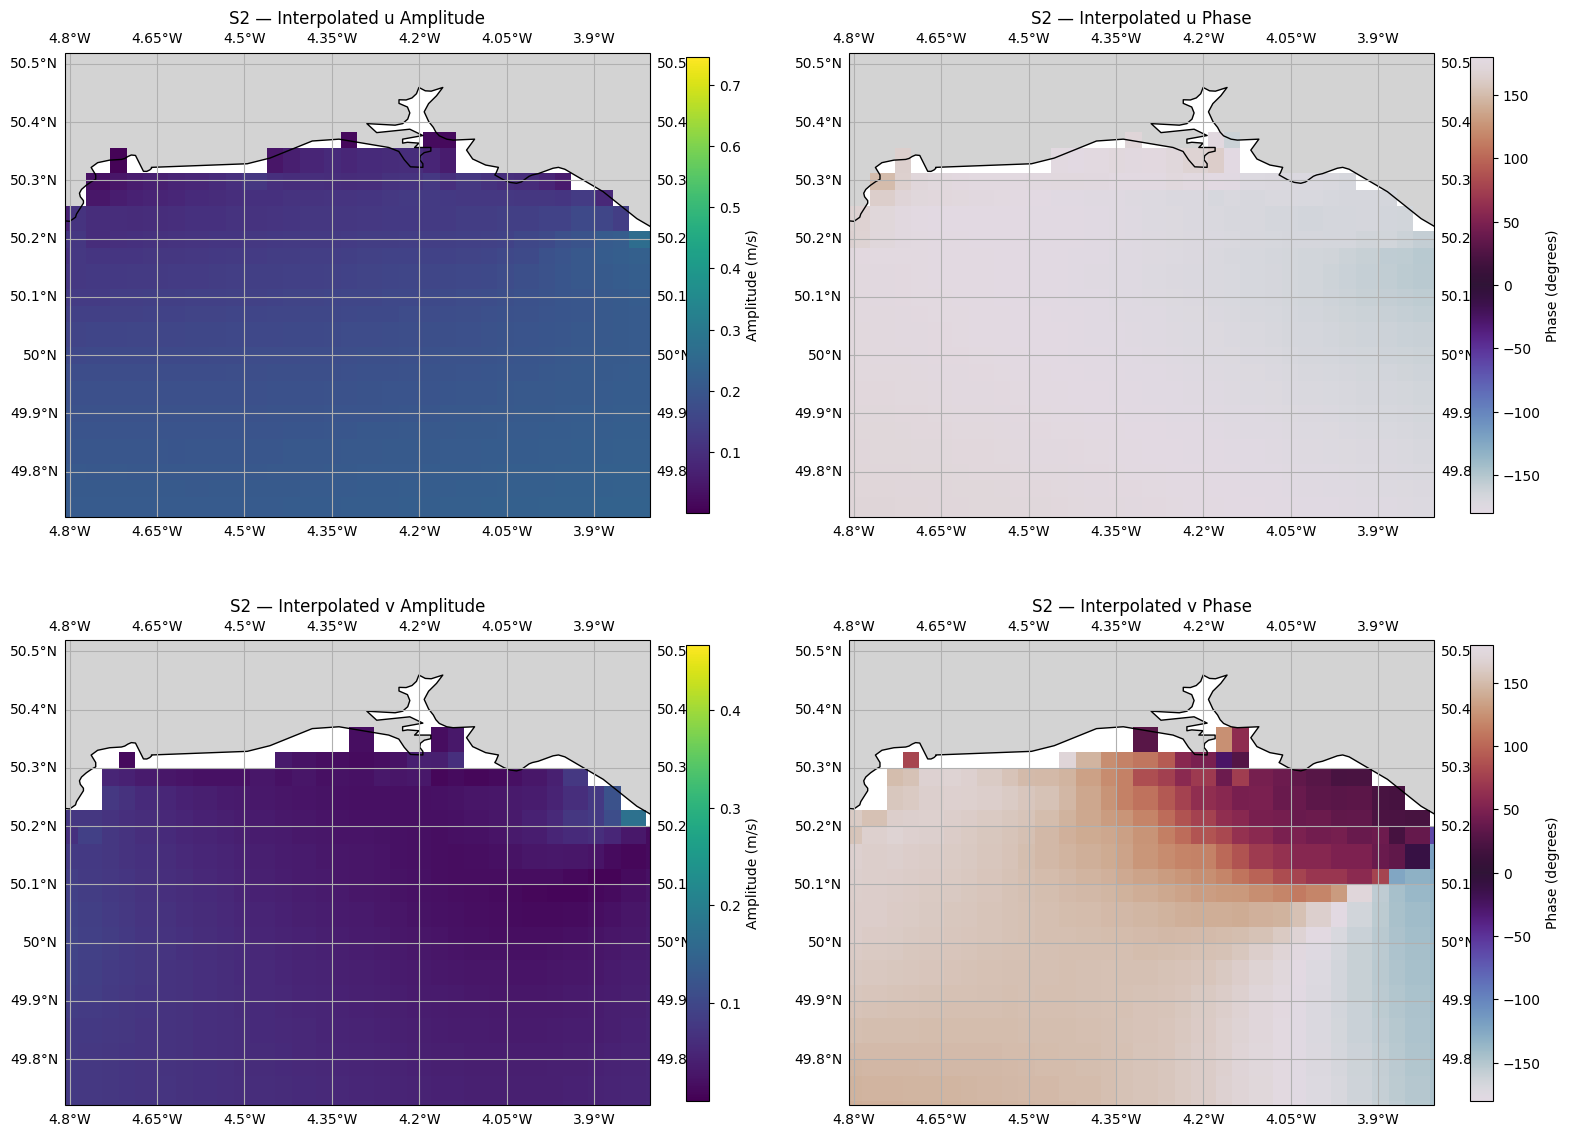

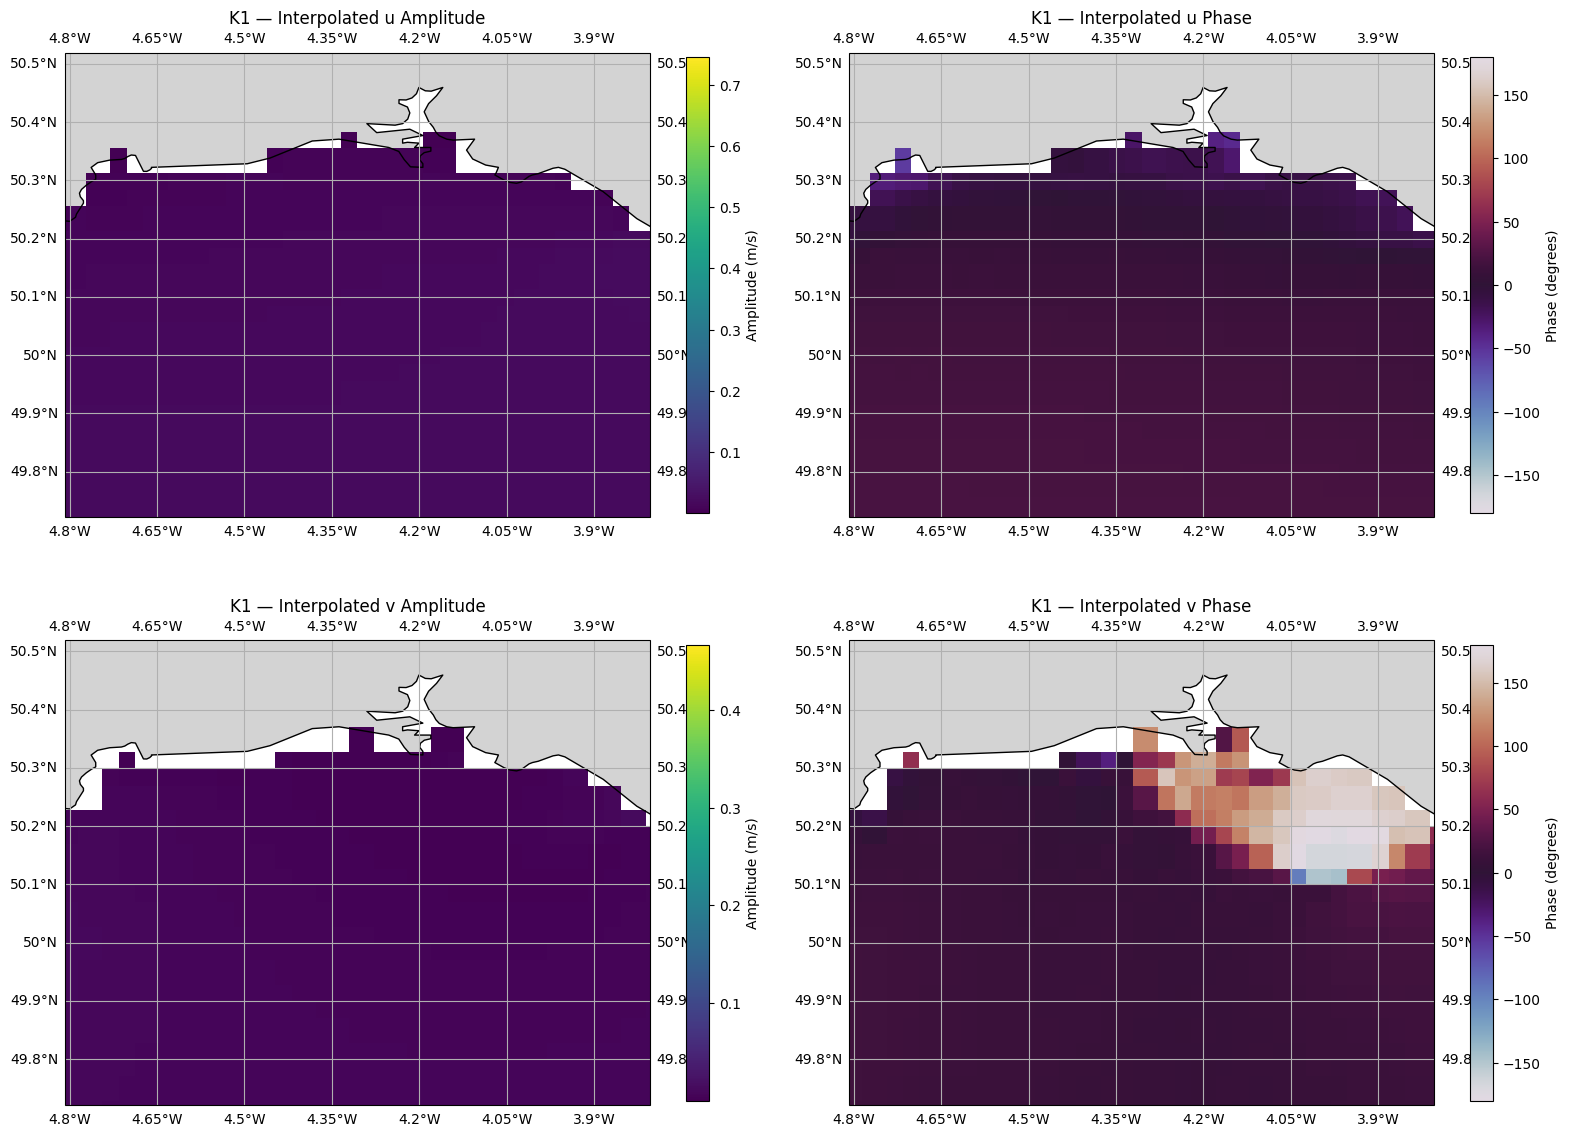

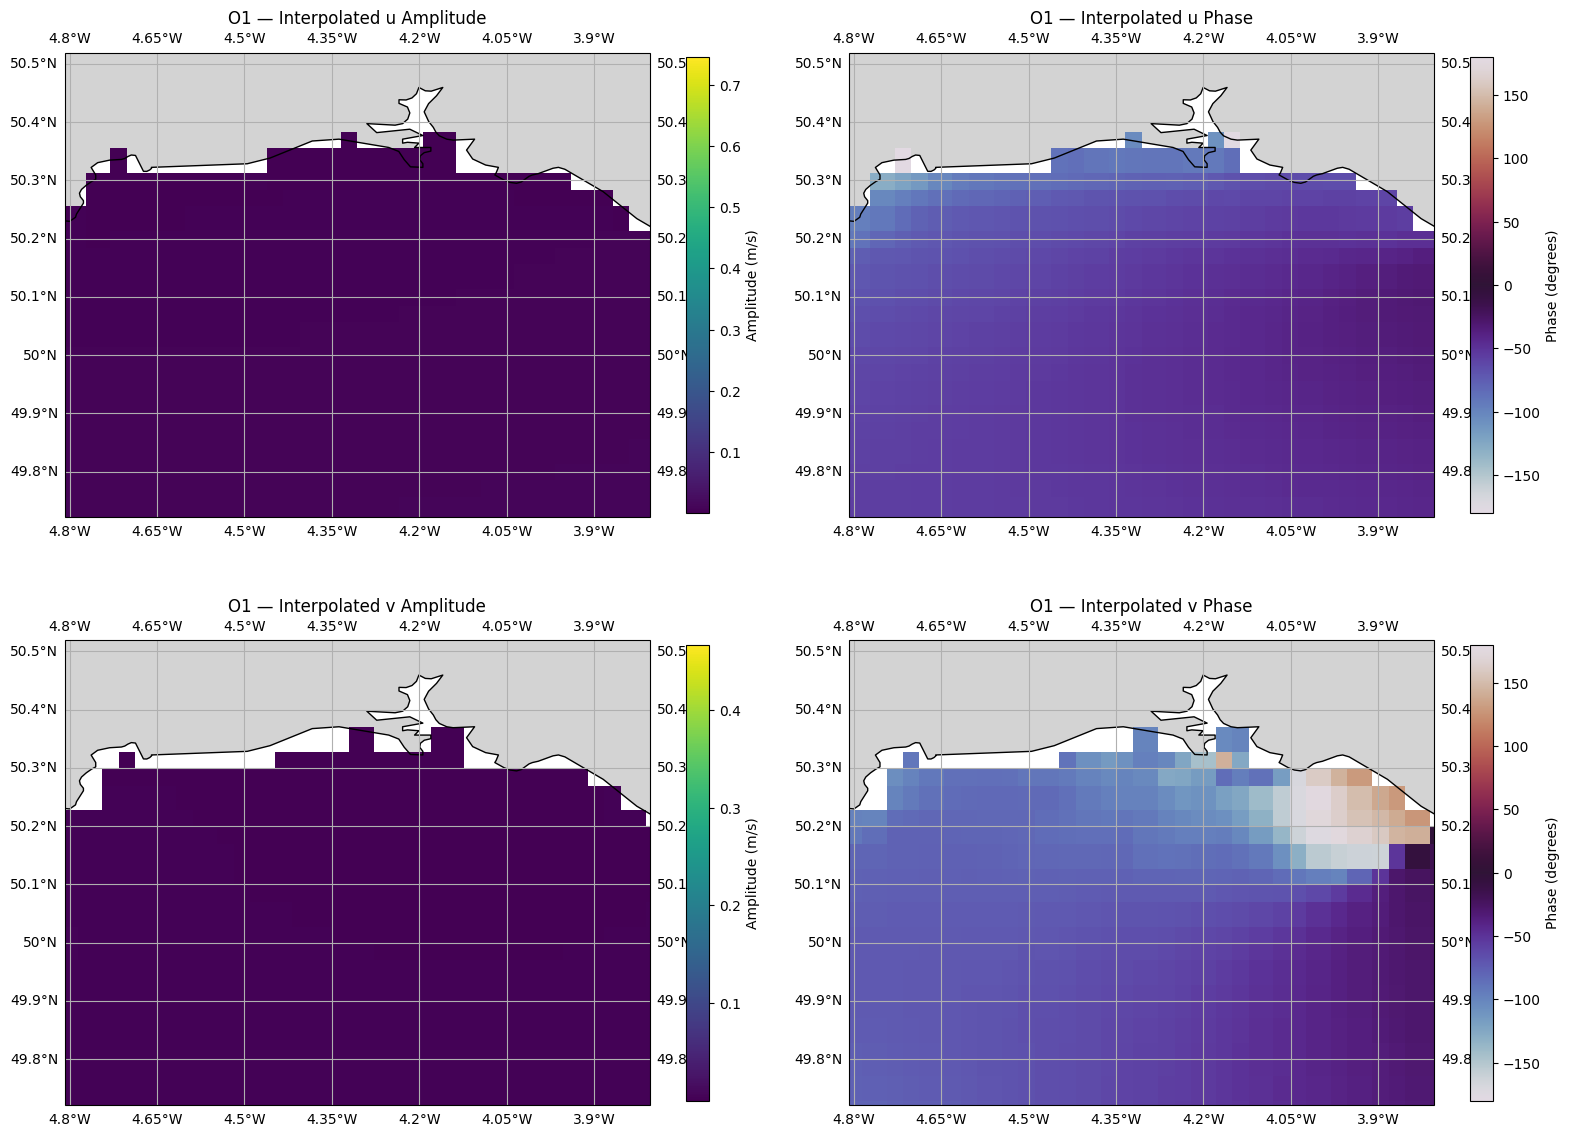

In [9]:
for c_idx, constituent in enumerate(constituents):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12),
                             subplot_kw={'projection': ccrs.PlateCarree()})

    # Reshape flat interpolated data back to 2D grid
    u_amp_2d = u_result.amplitudes[:, c_idx].reshape(n_lon, n_lat)
    u_phase_2d = u_result.phases[:, c_idx].reshape(n_lon, n_lat)
    v_amp_2d = v_result.amplitudes[:, c_idx].reshape(n_lon, n_lat)
    v_phase_2d = v_result.phases[:, c_idx].reshape(n_lon, n_lat)

    # u amplitude
    pc = axes[0, 0].pcolormesh(lon_2D, lat_2D, u_amp_2d, cmap='viridis',
                               transform=ccrs.PlateCarree(), shading='auto',
                               vmin=u_amp_vmin, vmax=u_amp_vmax)
    axes[0, 0].coastlines(resolution='10m')
    axes[0, 0].add_feature(cfeature.LAND, facecolor='lightgrey')
    axes[0, 0].gridlines(draw_labels=True)
    axes[0, 0].set_extent(extent, crs=ccrs.PlateCarree())
    cbar = plt.colorbar(pc, ax=axes[0, 0], shrink=0.8)
    cbar.set_label('Amplitude (m/s)')
    axes[0, 0].set_title(f'{constituent} — Interpolated u Amplitude')

    # u phase
    pc = axes[0, 1].pcolormesh(lon_2D, lat_2D, u_phase_2d, cmap='twilight',
                               transform=ccrs.PlateCarree(), shading='auto',
                               vmin=-180, vmax=180)
    axes[0, 1].coastlines(resolution='10m')
    axes[0, 1].add_feature(cfeature.LAND, facecolor='lightgrey')
    axes[0, 1].gridlines(draw_labels=True)
    axes[0, 1].set_extent(extent, crs=ccrs.PlateCarree())
    cbar = plt.colorbar(pc, ax=axes[0, 1], shrink=0.8)
    cbar.set_label('Phase (degrees)')
    axes[0, 1].set_title(f'{constituent} — Interpolated u Phase')

    # v amplitude
    pc = axes[1, 0].pcolormesh(lon_2D, lat_2D, v_amp_2d, cmap='viridis',
                               transform=ccrs.PlateCarree(), shading='auto',
                               vmin=v_amp_vmin, vmax=v_amp_vmax)
    axes[1, 0].coastlines(resolution='10m')
    axes[1, 0].add_feature(cfeature.LAND, facecolor='lightgrey')
    axes[1, 0].gridlines(draw_labels=True)
    axes[1, 0].set_extent(extent, crs=ccrs.PlateCarree())
    cbar = plt.colorbar(pc, ax=axes[1, 0], shrink=0.8)
    cbar.set_label('Amplitude (m/s)')
    axes[1, 0].set_title(f'{constituent} — Interpolated v Amplitude')

    # v phase
    pc = axes[1, 1].pcolormesh(lon_2D, lat_2D, v_phase_2d, cmap='twilight',
                               transform=ccrs.PlateCarree(), shading='auto',
                               vmin=-180, vmax=180)
    axes[1, 1].coastlines(resolution='10m')
    axes[1, 1].add_feature(cfeature.LAND, facecolor='lightgrey')
    axes[1, 1].gridlines(draw_labels=True)
    axes[1, 1].set_extent(extent, crs=ccrs.PlateCarree())
    cbar = plt.colorbar(pc, ax=axes[1, 1], shrink=0.8)
    cbar.set_label('Phase (degrees)')
    axes[1, 1].set_title(f'{constituent} — Interpolated v Phase')

    plt.tight_layout()
    plt.show()